# 🎵 Song Recommendation System — Extended

Extending the Kaggle recommendation notebooks with enriched features from `dataset_v6.csv`.

**Methods** (simple → advanced):
1. Content-Based (audio features + MinMaxScaler + cosine similarity)
2. Hybrid (content + weighted popularity)
3. Extended Content-Based (add lyric + preview audio features)
4. Embedding-Based (text + audio + image embeddings)
5. Learnable Fusion (PyTorch, genre-match optimisation)

**Stack**: Polars · scikit-learn · PyTorch (bf16 on CUDA)

In [1]:
from __future__ import annotations

import os, re, warnings, random
from pathlib import Path
from collections import Counter

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler, normalize
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE  = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float32
print(f'Device: {DEVICE}  |  Precision: {DTYPE}')

Device: cuda  |  Precision: torch.bfloat16


In [2]:
ROOT = Path.cwd()
CSV_PATH = ROOT / 'spotify_5000.parquet'
CACHE_DIR = ROOT / 'feature_cache'

use_cols = [
    'track_id', 'track_name', 'artists', 'album_name',
    'popularity', 'explicit',
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature',
    'track_genre', 'duration_ms', 'release_date',
    'cover_downloaded', 'preview_downloaded',
]

df = pl.read_csv(
    CSV_PATH, columns=use_cols,
    ignore_errors=True, infer_schema_length=20_000,
)

df = (
    df
    .with_columns([
        pl.col('track_id').cast(pl.Utf8),
        pl.col('track_name').fill_null('Unknown'),
        pl.col('artists').fill_null('Unknown'),
        pl.col('track_genre').fill_null('unknown'),
        pl.col('popularity').cast(pl.Float64, strict=False).fill_null(0.0),
        pl.col('release_date').fill_null('2020-01-01').cast(pl.Utf8),
    ])
    .filter(pl.col('track_id').is_not_null())
    .unique(subset=['track_id'], keep='first')
)

# Build lookup structures
track_ids = df['track_id'].to_list()
id_to_idx = {tid: i for i, tid in enumerate(track_ids)}

print(f'Tracks: {len(track_ids):,}')
print(f'Genres: {df["track_genre"].n_unique()}')

Tracks: 68,456
Genres: 113


In [3]:
# Change these values to inspect a different song throughout the notebook.
SELECTED_TRACK_NAME = 'Blinding Lights'
SELECTED_ARTIST = None  # e.g. 'The Weeknd'


def resolve_seed_track(data: pl.DataFrame, track_name: str, artist: str | None = None) -> dict:
    track_name = track_name.strip()
    artist = artist.strip() if artist else None

    candidates = data.filter(
        pl.col('track_name').str.to_lowercase() == track_name.lower()
    )
    if artist:
        candidates = candidates.filter(
            pl.col('artists').str.to_lowercase().str.contains(artist.lower(), literal=True)
        )

    if candidates.is_empty():
        candidates = data.filter(
            pl.col('track_name').str.to_lowercase().str.contains(track_name.lower(), literal=True)
        )
        if artist:
            candidates = candidates.filter(
                pl.col('artists').str.to_lowercase().str.contains(artist.lower(), literal=True)
            )

    if candidates.is_empty():
        raise ValueError(
            f"No track found for track_name={track_name!r}"
            + (f" and artist={artist!r}" if artist else '')
        )

    return candidates.sort('popularity', descending=True).row(0, named=True)


seed = resolve_seed_track(df, SELECTED_TRACK_NAME, SELECTED_ARTIST)
SEED_ID = seed['track_id']
print(f"Selected song: {seed['track_name']} — {seed['artists']} [{seed['track_genre']}]")

Selected song: Blinding Lights — The Weeknd [pop]


## Exploratory Data Analysis

Extending Kaggle EDA with outlier analysis (IQR) and feature independence plots.

Outlier counts (IQR method):
shape: (9, 3)
┌──────────────────┬──────────┬────────────┐
│ Feature          ┆ Outliers ┆ % Outliers │
│ ---              ┆ ---      ┆ ---        │
│ str              ┆ i64      ┆ str        │
╞══════════════════╪══════════╪════════════╡
│ danceability     ┆ 274      ┆ 0.4%       │
│ energy           ┆ 0        ┆ 0.0%       │
│ loudness         ┆ 2440     ┆ 3.6%       │
│ speechiness      ┆ 7772     ┆ 11.4%      │
│ acousticness     ┆ 0        ┆ 0.0%       │
│ instrumentalness ┆ 15068    ┆ 22.0%      │
│ liveness         ┆ 5001     ┆ 7.3%       │
│ valence          ┆ 0        ┆ 0.0%       │
│ tempo            ┆ 173      ┆ 0.3%       │
└──────────────────┴──────────┴────────────┘


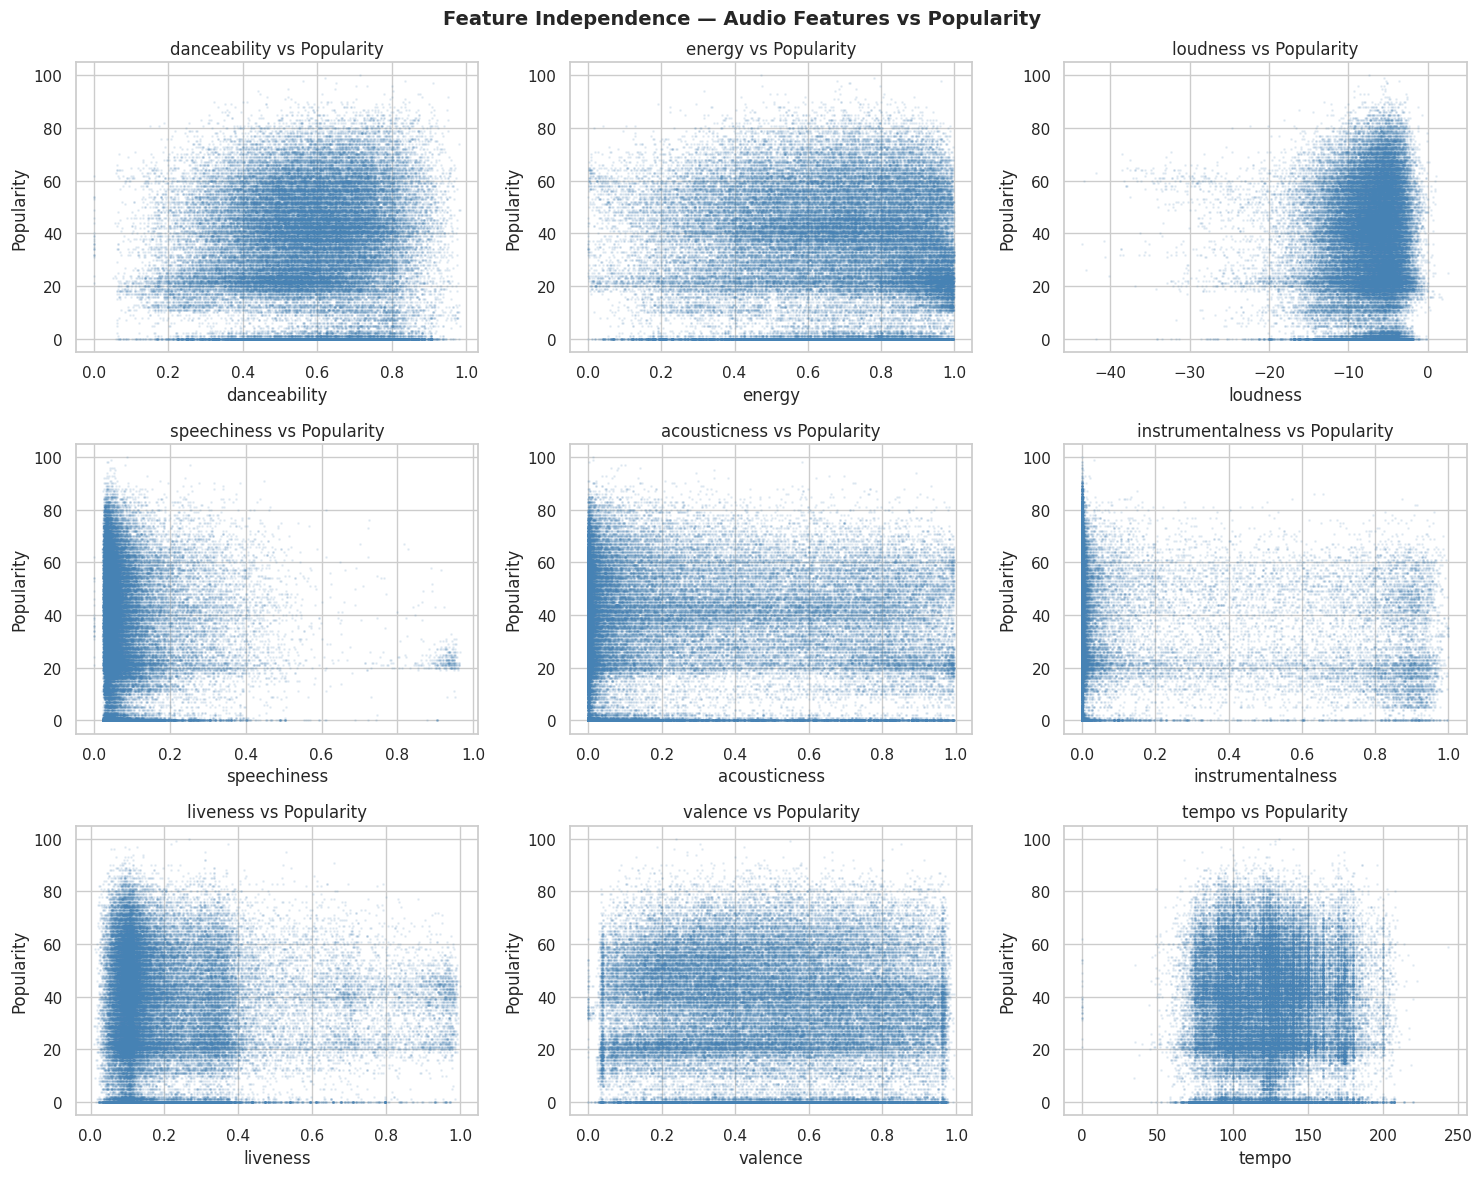

In [4]:
AUDIO_COLS = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
]

# Outlier analysis using IQR (extending kaggle approach)
def detect_outliers_iqr(series: pl.Series) -> int:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())

print('Outlier counts (IQR method):')
outlier_data = []
for col in AUDIO_COLS:
    n_out = detect_outliers_iqr(df[col].cast(pl.Float64, strict=False).fill_null(0))
    outlier_data.append({'Feature': col, 'Outliers': n_out,
                         '% Outliers': f'{100*n_out/len(df):.1f}%'})
print(pl.DataFrame(outlier_data))

# Feature independence scatter plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()
pop_vals = df['popularity'].to_numpy()
for i, col in enumerate(AUDIO_COLS):
    vals = df[col].cast(pl.Float64, strict=False).fill_null(0).to_numpy()
    axes[i].scatter(vals, pop_vals, alpha=0.1, s=1, c='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Popularity')
    axes[i].set_title(f'{col} vs Popularity')
plt.suptitle('Feature Independence — Audio Features vs Popularity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Method 1 — Content-Based Recommender

Matching the Kaggle approach: **MinMaxScaler** on audio features → cosine similarity.

This directly extends `generating-recommendations-from-ur-spotify-acc.ipynb`.

In [5]:
CONTENT_FEATURES = [
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature', 'duration_ms',
]

for c in CONTENT_FEATURES:
    df = df.with_columns(
        pl.col(c).cast(pl.Float64, strict=False).fill_null(pl.col(c).median())
    )

X_content = df.select(CONTENT_FEATURES).to_numpy().astype(np.float32)

# MinMaxScaler (matching Kaggle)
mm_scaler = MinMaxScaler()
X_content_mm = mm_scaler.fit_transform(X_content)

print(f'Content feature matrix: {X_content_mm.shape}')

Content feature matrix: (68456, 13)


In [6]:
def _exclude_seed_song_rows(rows: pl.DataFrame, seed_id: str) -> pl.DataFrame:
    seed_name_norm = str(seed['track_name']).strip().lower()
    seed_artist_norm = str(seed['artists']).strip().lower()

    name_expr = pl.col('track_name').cast(pl.Utf8, strict=False).fill_null('').str.to_lowercase().str.strip_chars()
    artist_expr = pl.col('artists').cast(pl.Utf8, strict=False).fill_null('').str.to_lowercase().str.strip_chars()

    same_name = name_expr == seed_name_norm
    same_artist = artist_expr == seed_artist_norm
    contains_seed_artist = artist_expr.str.contains(seed_artist_norm, literal=True) if seed_artist_norm else pl.lit(False)

    is_seed_variant = (pl.col('track_id').cast(pl.Utf8, strict=False) == seed_id) | (same_name & (same_artist | contains_seed_artist))
    return rows.filter(~is_seed_variant)


def _dedupe_playlist_rows(rows: pl.DataFrame) -> pl.DataFrame:
    # Remove duplicate tracks even when duplicated under different IDs/genres.
    return (
        rows
        .with_columns([
            pl.col('track_name').cast(pl.Utf8, strict=False).fill_null('').str.to_lowercase().str.strip_chars().alias('__name_norm'),
            pl.col('artists').cast(pl.Utf8, strict=False).fill_null('').str.to_lowercase().str.strip_chars().alias('__artist_norm'),
        ])
        .unique(subset=['__name_norm', '__artist_norm'], keep='first', maintain_order=True)
        .drop(['__name_norm', '__artist_norm'])
    )


def recommend_content(seed_id: str, feature_matrix: np.ndarray,
                      n: int = 40) -> pl.DataFrame:
    """Content-based recommendations using cosine similarity."""
    idx = id_to_idx[seed_id]
    sims = cosine_similarity(feature_matrix[idx:idx+1], feature_matrix).ravel()
    sims[idx] = -1.0

    ranked = np.argsort(-sims)
    out = (
        pl.DataFrame({
            'track_id': [track_ids[i] for i in ranked],
            'similarity': [float(sims[i]) for i in ranked],
        })
        .join(df.select(['track_id', 'track_name', 'artists', 'track_genre']),
              on='track_id', how='left')
    )
    out = _exclude_seed_song_rows(out, seed_id)
    out = _dedupe_playlist_rows(out)
    out = out.with_row_index('rank', offset=1)
    return out.select(['rank', 'track_name', 'artists', 'track_genre', 'similarity']).head(n)

print(f"Content playlist for: {seed['track_name']}")
playlist_content = recommend_content(SEED_ID, X_content_mm)
print(playlist_content)

Content playlist for: Blinding Lights
shape: (40, 5)
┌──────┬─────────────────────────────────┬───────────────────────┬───────────────────┬────────────┐
│ rank ┆ track_name                      ┆ artists               ┆ track_genre       ┆ similarity │
│ ---  ┆ ---                             ┆ ---                   ┆ ---               ┆ ---        │
│ u32  ┆ str                             ┆ str                   ┆ str               ┆ f64        │
╞══════╪═════════════════════════════════╪═══════════════════════╪═══════════════════╪════════════╡
│ 1    ┆ Thinkin About                   ┆ ShockOne;Lee Mvtthews ┆ drum-and-bass     ┆ 0.999386   │
│ 2    ┆ The Mother We Share             ┆ CHVRCHES              ┆ synth-pop         ┆ 0.999082   │
│ 3    ┆ Twilight Night                  ┆ NEO JAPONISM          ┆ j-idol            ┆ 0.998563   │
│ 4    ┆ Learn To Love Again             ┆ Audien                ┆ progressive-house ┆ 0.998237   │
│ 5    ┆ Frame of Mind                   ┆ Tris

---
## Method 2 — Hybrid Recommender (Content + Weighted Popularity)

Extending the Kaggle hybrid approach: combine content similarity with a time-decay-weighted popularity score.

In [7]:
from datetime import datetime

# Compute recency weight (newer = higher weight)
def release_date_weight(date_str: str) -> float:
    """Calculate time-decay weight: more recent songs get higher weight."""
    try:
        # Handle various date formats
        for fmt in ('%Y-%m-%d', '%Y-%m', '%Y'):
            try:
                dt = datetime.strptime(str(date_str)[:len(fmt.replace('%', 'X').replace('X', 'XX'))], fmt)
                break
            except ValueError:
                continue
        else:
            return 0.5
        days_since = (datetime(2026, 1, 1) - dt).days
        # Exponential decay with half-life of ~3 years
        return float(np.exp(-days_since / (365 * 3)))
    except Exception:
        return 0.5

# Compute weighted popularity
recency_weights = df['release_date'].map_elements(release_date_weight, return_dtype=pl.Float64).to_numpy()
raw_popularity = df['popularity'].to_numpy().astype(np.float64)

# Normalize both to [0, 1]
pop_norm = raw_popularity / max(raw_popularity.max(), 1)
recency_norm = recency_weights / max(recency_weights.max(), 1e-8)
weighted_popularity = 0.7 * pop_norm + 0.3 * recency_norm

print(f'Weighted popularity range: [{weighted_popularity.min():.3f}, {weighted_popularity.max():.3f}]')

Weighted popularity range: [0.000, 0.801]


In [9]:
def recommend_hybrid(seed_id: str, feature_matrix: np.ndarray,
                     n: int = 40, alpha: float = 0.7) -> pl.DataFrame:
    """
    Hybrid recommendations: alpha * content_similarity + (1-alpha) * weighted_popularity.
    Alpha controls the balance (0.7 = mostly content-driven).
    """
    idx = id_to_idx[seed_id]
    content_sims = cosine_similarity(feature_matrix[idx:idx+1], feature_matrix).ravel()

    hybrid_scores = alpha * content_sims + (1 - alpha) * weighted_popularity
    hybrid_scores[idx] = -1

    ranked = np.argsort(-hybrid_scores)
    out = (
        pl.DataFrame({
            'track_id': [track_ids[i] for i in ranked],
            'hybrid_score': [float(hybrid_scores[i]) for i in ranked],
        })
        .join(df.select(['track_id', 'track_name', 'artists', 'track_genre', 'popularity']),
              on='track_id', how='left')
    )
    out = _exclude_seed_song_rows(out, seed_id)
    out = _dedupe_playlist_rows(out)
    out = out.with_row_index('rank', offset=1)
    return out.select(['rank', 'track_name', 'artists', 'track_genre', 'popularity', 'hybrid_score']).head(n)

print(f"Hybrid playlist for: {seed['track_name']}")
playlist_hybrid = recommend_hybrid(SEED_ID, X_content_mm)
print(playlist_hybrid)

Hybrid playlist for: Blinding Lights
shape: (40, 6)
┌──────┬────────────────────────┬────────────────────────┬─────────────┬────────────┬──────────────┐
│ rank ┆ track_name             ┆ artists                ┆ track_genre ┆ popularity ┆ hybrid_score │
│ ---  ┆ ---                    ┆ ---                    ┆ ---         ┆ ---        ┆ ---          │
│ u32  ┆ str                    ┆ str                    ┆ str         ┆ f64        ┆ f64          │
╞══════╪════════════════════════╪════════════════════════╪═════════════╪════════════╪══════════════╡
│ 1    ┆ Quevedo: Bzrp Music    ┆ Bizarrap;Quevedo       ┆ hip-hop     ┆ 99.0       ┆ 0.925281     │
│      ┆ Sessions, …            ┆                        ┆             ┆            ┆              │
│ 2    ┆ Unholy (feat. Kim      ┆ Sam Smith;Kim Petras   ┆ dance       ┆ 100.0      ┆ 0.922579     │
│      ┆ Petras)                ┆                        ┆             ┆            ┆              │
│ 3    ┆ Jimmy Cooks (feat. 21  ┆ Drake

---
## Method 3 — Extended Content-Based

Go beyond the basic Kaggle approach by adding **lyric features** and **audio preview features** to the content filtering.

In [10]:
# Load cached features if available
LYRIC_FEATS = [
    'lyric_token_count', 'lyric_unique_token_ratio', 'lyric_avg_token_len',
    'lyric_long_word_ratio', 'lyric_repeat_ratio', 'lyric_top_token_share',
    'lyric_line_count', 'lyric_punctuation_density', 'lyric_entropy',
]
PREVIEW_FEATS = [
    'prev_duration', 'prev_rms_mean', 'prev_zcr_mean',
    'prev_centroid_mean', 'prev_bandwidth_mean', 'prev_tempo_est',
]

lyric_cache = CACHE_DIR / 'lyric_features.parquet'
audio_cache = CACHE_DIR / 'preview_audio_features.parquet'

if lyric_cache.exists():
    lyric_df = pl.read_parquet(lyric_cache)
    df = df.join(lyric_df, on='track_id', how='left', suffix='_dup')
    print(f'Loaded lyric features')

if audio_cache.exists():
    audio_df = pl.read_parquet(audio_cache)
    df = df.join(audio_df, on='track_id', how='left', suffix='_dup')
    print(f'Loaded preview audio features')

# Build extended feature set
available_lyric = [c for c in LYRIC_FEATS if c in df.columns]
available_preview = [c for c in PREVIEW_FEATS if c in df.columns]
extended_cols = CONTENT_FEATURES + available_lyric + available_preview

for c in available_lyric + available_preview:
    df = df.with_columns(
        pl.col(c).cast(pl.Float64, strict=False).fill_null(pl.col(c).median())
    )

X_extended = df.select(extended_cols).to_numpy().astype(np.float32)
X_extended = np.nan_to_num(X_extended, nan=0.0)

mm_ext = MinMaxScaler()
X_extended_mm = mm_ext.fit_transform(X_extended)

# Refresh lookup (df may have changed size after joins)
track_ids = df['track_id'].to_list()
id_to_idx = {tid: i for i, tid in enumerate(track_ids)}

print(f'Extended feature matrix: {X_extended_mm.shape} ({len(extended_cols)} features)')
print(f'  Base audio: {len(CONTENT_FEATURES)}')
print(f'  + Lyric: {len(available_lyric)}')
print(f'  + Preview: {len(available_preview)}')

Loaded lyric features
Loaded preview audio features
Extended feature matrix: (68456, 28) (28 features)
  Base audio: 13
  + Lyric: 9
  + Preview: 6


In [11]:
print(f"Extended content playlist for: {seed['track_name']}")
playlist_extended = recommend_content(SEED_ID, X_extended_mm)
print(playlist_extended)

Extended content playlist for: Blinding Lights
shape: (40, 5)
┌──────┬───────────────────────────┬─────────────────────────────────┬─────────────┬────────────┐
│ rank ┆ track_name                ┆ artists                         ┆ track_genre ┆ similarity │
│ ---  ┆ ---                       ┆ ---                             ┆ ---         ┆ ---        │
│ u32  ┆ str                       ┆ str                             ┆ str         ┆ f64        │
╞══════╪═══════════════════════════╪═════════════════════════════════╪═════════════╪════════════╡
│ 1    ┆ The Mother We Share       ┆ CHVRCHES                        ┆ synth-pop   ┆ 0.998098   │
│ 2    ┆ Emotion Sickness          ┆ Said The Sky;Parachute;Will An… ┆ dub         ┆ 0.996838   │
│ 3    ┆ Apologize                 ┆ Silverstein                     ┆ metalcore   ┆ 0.996697   │
│ 4    ┆ Majesty (Here I Am)       ┆ Hillsong Worship;Delirious?     ┆ world-music ┆ 0.996602   │
│ 5    ┆ Broken                    ┆ William Black;Fairl

---
## Method 4 — Deep Metric Recommenders (Tuned)

Add two more complex neural recommenders trained on the extended feature matrix:

1. **Denoising Autoencoder Recommender (DAE)**
2. **Residual Metric Recommender (ResNet-style embedding model)**

Both are tuned via random-search hyperparameter tuning and evaluated using a recommendation-quality proxy:
- **Genre hit-rate@40** (semantic match)
- **Content alignment@40** (cosine on engineered features)

Final playlists remain fixed at **40 songs**.


In [12]:
# ===== Deep recommenders: common data setup =====
all_X = X_extended_mm.astype(np.float32)
N_ITEMS, N_FEATS = all_X.shape

genre_values = df['track_genre'].to_list()
genre_vocab = sorted(set(genre_values))
genre_to_idx = {g: i for i, g in enumerate(genre_vocab)}
all_genre_idx = np.array([genre_to_idx[g] for g in genre_values], dtype=np.int64)
N_GENRES = len(genre_vocab)

rng = np.random.default_rng(SEED)
perm = rng.permutation(N_ITEMS)
cut = int(0.85 * N_ITEMS)
train_idx = perm[:cut]
val_idx = perm[cut:]

x_tensor = torch.from_numpy(all_X).float()
g_tensor = torch.from_numpy(all_genre_idx).long()

feat_norm = normalize(all_X, norm='l2', axis=1)


class ResidualFC(nn.Module):
    def __init__(self, dim: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.act(x + self.net(x))


class DAERecommender(nn.Module):
    def __init__(self, n_features: int, n_genres: int,
                 hidden_dim: int = 256, emb_dim: int = 64, dropout: float = 0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, emb_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(emb_dim, hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, n_features),
        )
        self.genre_head = nn.Linear(emb_dim, n_genres)

    def forward(self, x):
        emb = self.encoder(x)
        emb = F.normalize(emb, dim=-1)
        recon = self.decoder(emb)
        logits = self.genre_head(emb)
        return emb, recon, logits


class ResidualMetricRecommender(nn.Module):
    def __init__(self, n_features: int, n_genres: int,
                 hidden_dim: int = 256, emb_dim: int = 96,
                 n_blocks: int = 3, dropout: float = 0.2):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(n_features, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        self.blocks = nn.Sequential(*[ResidualFC(hidden_dim, dropout) for _ in range(n_blocks)])
        self.emb_layer = nn.Linear(hidden_dim, emb_dim)
        self.decoder = nn.Sequential(
            nn.Linear(emb_dim, hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim // 2, n_features),
        )
        self.genre_head = nn.Linear(emb_dim, n_genres)

    def forward(self, x):
        h = self.input_layer(x)
        h = self.blocks(h)
        emb = F.normalize(self.emb_layer(h), dim=-1)
        recon = self.decoder(emb)
        logits = self.genre_head(emb)
        return emb, recon, logits


def build_loader(indices: np.ndarray, batch_size: int, shuffle: bool):
    ds = torch.utils.data.TensorDataset(x_tensor[indices], g_tensor[indices])
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=2, pin_memory=(DEVICE.type == 'cuda'))


def recommendation_quality_at_40(emb_norm: np.ndarray, seed_indices: np.ndarray) -> float:
    # Proxy metric that aligns with recommendation quality in this notebook.
    # score = 0.7 * genre_hit@40 + 0.3 * content_cosine@40
    scores = []
    for s in seed_indices:
        sims = emb_norm @ emb_norm[s]
        sims[s] = -1.0
        top = np.argpartition(-sims, 40)[:40]

        genre_hit = float(np.mean(all_genre_idx[top] == all_genre_idx[s]))
        content_align = float(np.mean(feat_norm[top] @ feat_norm[s]))
        scores.append(0.7 * genre_hit + 0.3 * content_align)

    return float(np.mean(scores)) if scores else 0.0


def train_trial(model: nn.Module, cfg: dict, epochs: int = 18, patience: int = 5):
    train_loader = build_loader(train_idx, cfg['batch_size'], shuffle=True)
    val_loader = build_loader(val_idx, min(cfg['batch_size'] * 2, 4096), shuffle=False)

    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    mse = nn.MSELoss()
    ce = nn.CrossEntropyLoss()

    amp_dtype = DTYPE if DEVICE.type == 'cuda' else torch.float32
    scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))

    best_val = float('inf')
    best_state = None
    no_improve = 0

    for _epoch in range(1, epochs + 1):
        model.train()
        for xb, gb in train_loader:
            xb, gb = xb.to(DEVICE), gb.to(DEVICE)
            noise = torch.randn_like(xb) * cfg['noise_std']
            x_in = torch.clamp(xb + noise, 0.0, 1.0)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type='cuda', dtype=amp_dtype, enabled=(DEVICE.type == 'cuda')):
                _, recon, logits = model(x_in)
                recon_loss = mse(recon, xb)
                genre_loss = ce(logits, gb)
                loss = cfg['recon_w'] * recon_loss + cfg['genre_w'] * genre_loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        scheduler.step()

        model.eval()
        val_loss = 0.0
        count = 0
        with torch.no_grad():
            for xb, gb in val_loader:
                xb, gb = xb.to(DEVICE), gb.to(DEVICE)
                with torch.amp.autocast(device_type='cuda', dtype=amp_dtype, enabled=(DEVICE.type == 'cuda')):
                    _, recon, logits = model(xb)
                    recon_loss = mse(recon, xb)
                    genre_loss = ce(logits, gb)
                    loss = cfg['recon_w'] * recon_loss + cfg['genre_w'] * genre_loss
                val_loss += float(loss.item()) * len(xb)
                count += len(xb)

        val_loss /= max(count, 1)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        emb_all, _, _ = model(x_tensor.to(DEVICE))
    emb_np = emb_all.float().cpu().numpy()
    emb_np = normalize(emb_np, norm='l2', axis=1)

    # evaluate on a sample of validation seeds
    seed_sample = rng.choice(val_idx, size=min(512, len(val_idx)), replace=False)
    quality = recommendation_quality_at_40(emb_np, seed_sample)
    return model, emb_np, best_val, quality


def random_tune(model_name: str, model_builder, search_space: dict,
                n_trials: int = 8, tune_epochs: int = 18):
    rows = []
    best_payload = None

    for t in range(1, n_trials + 1):
        cfg = {k: random.choice(v) for k, v in search_space.items()}
        model = model_builder(cfg)

        trained_model, emb_np, val_loss, quality = train_trial(model, cfg, epochs=tune_epochs)

        row = {
            'trial': t,
            'model': model_name,
            'val_loss': val_loss,
            'quality_at_40': quality,
            **cfg,
        }
        rows.append(row)
        print(f"{model_name} trial {t}/{n_trials} | quality@40={quality:.4f} | cfg={cfg}")

        if (best_payload is None) or (quality > best_payload['quality_at_40']):
            best_payload = {
                'model': trained_model,
                'emb': emb_np,
                'quality_at_40': quality,
                'cfg': cfg,
                'val_loss': val_loss,
            }

    print(f"Best {model_name}: quality@40={best_payload['quality_at_40']:.4f} cfg={best_payload['cfg']}")
    return best_payload, pl.DataFrame(rows).sort('quality_at_40', descending=True)


def recommend_from_embedding(seed_id: str, emb_norm: np.ndarray, n: int = 40) -> pl.DataFrame:
    idx = id_to_idx[seed_id]
    sims = emb_norm @ emb_norm[idx]
    sims[idx] = -1.0  # hard-exclude seed track

    ranked = np.argsort(-sims)
    return (
        pl.DataFrame({
            'track_id': [track_ids[i] for i in ranked],
            'deep_score': [float(sims[i]) for i in ranked],
        })
        .with_row_index('rank', offset=1)
        .join(df.select(['track_id', 'track_name', 'artists', 'track_genre', 'popularity']),
              on='track_id', how='left')
        .filter(pl.col('track_id') != seed_id)
        .select(['rank', 'track_name', 'artists', 'track_genre', 'popularity', 'deep_score'])
        .head(n)
    )


In [13]:
# ===== Hyperparameter tuning =====
DAE_SPACE = {
    'hidden_dim': [192, 256, 320, 384],
    'emb_dim': [48, 64, 96],
    'dropout': [0.10, 0.20, 0.30],
    'lr': [2e-4, 5e-4, 8e-4, 1e-3],
    'weight_decay': [1e-6, 1e-5, 1e-4],
    'batch_size': [256, 512, 1024],
    'noise_std': [0.00, 0.01, 0.02, 0.03],
    'recon_w': [1.0, 1.5, 2.0],
    'genre_w': [0.3, 0.5, 0.7],
}

RESMETRIC_SPACE = {
    'hidden_dim': [192, 256, 320, 384],
    'emb_dim': [64, 96, 128],
    'n_blocks': [2, 3, 4],
    'dropout': [0.10, 0.20, 0.30],
    'lr': [2e-4, 5e-4, 8e-4, 1e-3],
    'weight_decay': [1e-6, 1e-5, 1e-4],
    'batch_size': [256, 512, 1024],
    'noise_std': [0.00, 0.01, 0.02, 0.03],
    'recon_w': [1.0, 1.5, 2.0],
    'genre_w': [0.3, 0.5, 0.7],
}

N_TRIALS = 8
TUNE_EPOCHS = 18

print('=== Tuning DAE Recommender ===')
dae_best, dae_trials = random_tune(
    'DAE Recommender',
    lambda cfg: DAERecommender(
        n_features=N_FEATS,
        n_genres=N_GENRES,
        hidden_dim=cfg['hidden_dim'],
        emb_dim=cfg['emb_dim'],
        dropout=cfg['dropout'],
    ),
    DAE_SPACE,
    n_trials=N_TRIALS,
    tune_epochs=TUNE_EPOCHS,
)

print('\n=== Tuning Residual Metric Recommender ===')
resmetric_best, resmetric_trials = random_tune(
    'Residual Metric Recommender',
    lambda cfg: ResidualMetricRecommender(
        n_features=N_FEATS,
        n_genres=N_GENRES,
        hidden_dim=cfg['hidden_dim'],
        emb_dim=cfg['emb_dim'],
        n_blocks=cfg['n_blocks'],
        dropout=cfg['dropout'],
    ),
    RESMETRIC_SPACE,
    n_trials=N_TRIALS,
    tune_epochs=TUNE_EPOCHS,
)

print('\n=== Tuning Leaderboard ===')
deep_tuning_results = pl.concat([dae_trials, resmetric_trials], how='diagonal').sort('quality_at_40', descending=True)
print(deep_tuning_results)


=== Tuning DAE Recommender ===
DAE Recommender trial 1/8 | quality@40=0.3752 | cfg={'hidden_dim': 192, 'emb_dim': 48, 'dropout': 0.3, 'lr': 0.0008, 'weight_decay': 1e-06, 'batch_size': 256, 'noise_std': 0.01, 'recon_w': 2.0, 'genre_w': 0.3}
DAE Recommender trial 2/8 | quality@40=0.3633 | cfg={'hidden_dim': 192, 'emb_dim': 96, 'dropout': 0.2, 'lr': 0.0002, 'weight_decay': 1e-06, 'batch_size': 256, 'noise_std': 0.01, 'recon_w': 1.0, 'genre_w': 0.7}
DAE Recommender trial 3/8 | quality@40=0.3730 | cfg={'hidden_dim': 192, 'emb_dim': 96, 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 1e-06, 'batch_size': 512, 'noise_std': 0.02, 'recon_w': 1.0, 'genre_w': 0.3}
DAE Recommender trial 4/8 | quality@40=0.3752 | cfg={'hidden_dim': 384, 'emb_dim': 64, 'dropout': 0.2, 'lr': 0.0005, 'weight_decay': 1e-06, 'batch_size': 512, 'noise_std': 0.0, 'recon_w': 1.0, 'genre_w': 0.5}
DAE Recommender trial 5/8 | quality@40=0.3637 | cfg={'hidden_dim': 192, 'emb_dim': 64, 'dropout': 0.2, 'lr': 0.0008, 'weight_decay'

In [14]:
# ===== Final 40-song deep playlists =====
def recommend_from_embedding(seed_id: str, emb_norm: np.ndarray, n: int = 40) -> pl.DataFrame:
    idx = id_to_idx[seed_id]
    sims = emb_norm @ emb_norm[idx]
    sims[idx] = -1.0

    ranked = np.argsort(-sims)
    out = (
        pl.DataFrame({
            'track_id': [track_ids[i] for i in ranked],
            'deep_score': [float(sims[i]) for i in ranked],
        })
        .join(df.select(['track_id', 'track_name', 'artists', 'track_genre', 'popularity']),
              on='track_id', how='left')
    )
    out = _exclude_seed_song_rows(out, seed_id)
    out = _dedupe_playlist_rows(out)
    out = out.with_row_index('rank', offset=1)
    return out.select(['rank', 'track_name', 'artists', 'track_genre', 'popularity', 'deep_score']).head(n)


playlist_deep_dae = recommend_from_embedding(SEED_ID, dae_best['emb'], n=40)
playlist_deep_resmetric = recommend_from_embedding(SEED_ID, resmetric_best['emb'], n=40)

dae_emb = dae_best['emb']
res_emb = resmetric_best['emb']
if dae_emb.shape[1] != res_emb.shape[1]:
    min_dim = min(dae_emb.shape[1], res_emb.shape[1])
    dae_emb = dae_emb[:, :min_dim]
    res_emb = res_emb[:, :min_dim]

ensemble_emb = normalize(0.5 * dae_emb + 0.5 * res_emb, norm='l2', axis=1)
playlist_deep_ensemble = recommend_from_embedding(SEED_ID, ensemble_emb, n=40)

print(f"Deep DAE playlist for: {seed['track_name']} (40 songs)")
print(playlist_deep_dae)

print(f"\nDeep Residual-Metric playlist for: {seed['track_name']} (40 songs)")
print(playlist_deep_resmetric)

print(f"\nDeep Ensemble playlist for: {seed['track_name']} (40 songs)")
print(playlist_deep_ensemble)

deep_quality_summary = pl.DataFrame([
    {'Model': 'DAE Recommender', 'quality_at_40': dae_best['quality_at_40'], 'val_loss': dae_best['val_loss']},
    {'Model': 'Residual Metric Recommender', 'quality_at_40': resmetric_best['quality_at_40'], 'val_loss': resmetric_best['val_loss']},
]).sort('quality_at_40', descending=True)

print('\n=== Deep Recommender Summary ===')
print(deep_quality_summary)


Deep DAE playlist for: Blinding Lights (40 songs)
shape: (40, 6)
┌──────┬────────────────────────────┬──────────────────────┬─────────────┬────────────┬────────────┐
│ rank ┆ track_name                 ┆ artists              ┆ track_genre ┆ popularity ┆ deep_score │
│ ---  ┆ ---                        ┆ ---                  ┆ ---         ┆ ---        ┆ ---        │
│ u32  ┆ str                        ┆ str                  ┆ str         ┆ f64        ┆ f64        │
╞══════╪════════════════════════════╪══════════════════════╪═════════════╪════════════╪════════════╡
│ 1    ┆ Part-Time Lover            ┆ Dabin;Claire Ridgely ┆ dub         ┆ 48.0       ┆ 0.978842   │
│ 2    ┆ Good as Hell - Two Stacks  ┆ Lizzo;Two Stacks     ┆ hip-hop     ┆ 0.0        ┆ 0.975344   │
│      ┆ Remi…                      ┆                      ┆             ┆            ┆            │
│ 3    ┆ Kids In America            ┆ Kim Wilde            ┆ disco       ┆ 70.0       ┆ 0.973222   │
│ 4    ┆ Skins            

In [15]:
# ===== Global seed-variant filter (applies to Methods 1–4) =====
SEED_NAME_NORM = str(seed['track_name']).strip().lower()
SEED_ARTIST_NORM = str(seed['artists']).strip().lower()


def _filter_out_seed_variants(frame: pl.DataFrame, seed_id: str) -> pl.DataFrame:
    if frame.is_empty():
        return frame

    name_expr = pl.col('track_name').cast(pl.Utf8, strict=False).fill_null('').str.to_lowercase().str.strip_chars()
    artist_expr = pl.col('artists').cast(pl.Utf8, strict=False).fill_null('').str.to_lowercase().str.strip_chars()

    same_name = name_expr == SEED_NAME_NORM
    same_artist = artist_expr == SEED_ARTIST_NORM
    contains_seed_artist = artist_expr.str.contains(SEED_ARTIST_NORM, literal=True) if SEED_ARTIST_NORM else pl.lit(False)

    is_seed_variant = (pl.col('track_id').cast(pl.Utf8, strict=False) == seed_id) | (same_name & (same_artist | contains_seed_artist))
    return frame.filter(~is_seed_variant)


def recommend_content(seed_id: str, feature_matrix: np.ndarray, n: int = 40) -> pl.DataFrame:
    idx = id_to_idx[seed_id]
    sims = cosine_similarity(feature_matrix[idx:idx + 1], feature_matrix).ravel()
    sims[idx] = -1.0

    ranked = np.argsort(-sims)
    out = (
        pl.DataFrame({
            'track_id': [track_ids[i] for i in ranked],
            'similarity': [float(sims[i]) for i in ranked],
        })
        .join(df.select(['track_id', 'track_name', 'artists', 'track_genre']), on='track_id', how='left')
    )
    out = _filter_out_seed_variants(out, seed_id).with_row_index('rank', offset=1)
    return out.select(['rank', 'track_name', 'artists', 'track_genre', 'similarity']).head(n)


def recommend_hybrid(seed_id: str, feature_matrix: np.ndarray, n: int = 40, alpha: float = 0.7) -> pl.DataFrame:
    idx = id_to_idx[seed_id]
    content_sims = cosine_similarity(feature_matrix[idx:idx + 1], feature_matrix).ravel()
    hybrid_scores = alpha * content_sims + (1 - alpha) * weighted_popularity
    hybrid_scores[idx] = -1.0

    ranked = np.argsort(-hybrid_scores)
    out = (
        pl.DataFrame({
            'track_id': [track_ids[i] for i in ranked],
            'hybrid_score': [float(hybrid_scores[i]) for i in ranked],
        })
        .join(df.select(['track_id', 'track_name', 'artists', 'track_genre', 'popularity']), on='track_id', how='left')
    )
    out = _filter_out_seed_variants(out, seed_id).with_row_index('rank', offset=1)
    return out.select(['rank', 'track_name', 'artists', 'track_genre', 'popularity', 'hybrid_score']).head(n)


def recommend_from_embedding(seed_id: str, emb_norm: np.ndarray, n: int = 40) -> pl.DataFrame:
    idx = id_to_idx[seed_id]
    sims = emb_norm @ emb_norm[idx]
    sims[idx] = -1.0

    ranked = np.argsort(-sims)
    out = (
        pl.DataFrame({
            'track_id': [track_ids[i] for i in ranked],
            'deep_score': [float(sims[i]) for i in ranked],
        })
        .join(df.select(['track_id', 'track_name', 'artists', 'track_genre', 'popularity']), on='track_id', how='left')
    )
    out = _filter_out_seed_variants(out, seed_id).with_row_index('rank', offset=1)
    return out.select(['rank', 'track_name', 'artists', 'track_genre', 'popularity', 'deep_score']).head(n)


print('Global seed-variant exclusion is now active for Methods 1–4.')


Global seed-variant exclusion is now active for Methods 1–4.


In [16]:
# ===== Validation: ensure seed is excluded from all playlists =====
def _count_seed_like(df_playlist: pl.DataFrame) -> int:
    if df_playlist.is_empty():
        return 0
    name_expr = pl.col('track_name').cast(pl.Utf8, strict=False).fill_null('').str.to_lowercase().str.strip_chars()
    artist_expr = pl.col('artists').cast(pl.Utf8, strict=False).fill_null('').str.to_lowercase().str.strip_chars()
    track_expr = pl.col('track_id').cast(pl.Utf8, strict=False) if 'track_id' in df_playlist.columns else pl.lit('')

    same = (
        (track_expr == SEED_ID)
        | ((name_expr == SEED_NAME_NORM) & (artist_expr.str.contains(SEED_ARTIST_NORM, literal=True)))
    )
    return int(df_playlist.select(same.sum().alias('cnt'))['cnt'][0])

playlist_checks = {
    'Method 1: Content': playlist_content,
    'Method 2: Hybrid': playlist_hybrid,
    'Method 3: Extended Content': playlist_extended,
    'Method 4: Deep DAE': playlist_deep_dae,
    'Method 4: Deep Residual': playlist_deep_resmetric,
    'Method 4: Deep Ensemble': playlist_deep_ensemble,
}

check_rows = []
for name, p in playlist_checks.items():
    seed_like = _count_seed_like(p)
    check_rows.append({'Playlist': name, 'rows': p.height, 'seed_like_rows': seed_like, 'ok': seed_like == 0})

seed_filter_report = pl.DataFrame(check_rows)
print(seed_filter_report)

if not seed_filter_report['ok'].all():
    raise AssertionError('Seed track/variant still appears in at least one playlist.')

print('\nAll playlists pass: seed track is excluded across Methods 1–4.')


shape: (6, 4)
┌────────────────────────────┬──────┬────────────────┬──────┐
│ Playlist                   ┆ rows ┆ seed_like_rows ┆ ok   │
│ ---                        ┆ ---  ┆ ---            ┆ ---  │
│ str                        ┆ i64  ┆ i64            ┆ bool │
╞════════════════════════════╪══════╪════════════════╪══════╡
│ Method 1: Content          ┆ 40   ┆ 0              ┆ true │
│ Method 2: Hybrid           ┆ 40   ┆ 0              ┆ true │
│ Method 3: Extended Content ┆ 40   ┆ 0              ┆ true │
│ Method 4: Deep DAE         ┆ 40   ┆ 0              ┆ true │
│ Method 4: Deep Residual    ┆ 40   ┆ 0              ┆ true │
│ Method 4: Deep Ensemble    ┆ 40   ┆ 0              ┆ true │
└────────────────────────────┴──────┴────────────────┴──────┘

All playlists pass: seed track is excluded across Methods 1–4.


---
## Final Playlist Summary (All Models, with track_id)

This section rebuilds each final 40-song playlist with explicit `track_id`, then prints:
- a compact cross-model summary table,
- a combined long-format table,
- and per-model previews.


In [17]:
# ===== Build ID-inclusive final playlists for all models =====

def _playlist_from_scores(seed_id: str, scores: np.ndarray, score_col: str) -> pl.DataFrame:
    idx = id_to_idx[seed_id]
    arr = scores.copy()
    arr[idx] = -1.0
    ranked = np.argsort(-arr)

    out = (
        pl.DataFrame({
            'track_id': [track_ids[i] for i in ranked],
            score_col: [float(arr[i]) for i in ranked],
        })
        .join(df.select(['track_id', 'track_name', 'artists', 'track_genre', 'popularity']),
              on='track_id', how='left')
    )
    out = _exclude_seed_song_rows(out, seed_id)
    out = _dedupe_playlist_rows(out)
    out = out.with_row_index('rank', offset=1).head(40)
    return out.select(['rank', 'track_id', 'track_name', 'artists', 'track_genre', 'popularity', score_col])


seed_idx = id_to_idx[SEED_ID]

# Method 1: Content
content_scores = cosine_similarity(X_content_mm[seed_idx:seed_idx + 1], X_content_mm).ravel()
playlist_content_id = _playlist_from_scores(SEED_ID, content_scores, 'similarity')

# Method 2: Hybrid
HYBRID_ALPHA = 0.7
hybrid_scores = HYBRID_ALPHA * content_scores + (1 - HYBRID_ALPHA) * weighted_popularity
playlist_hybrid_id = _playlist_from_scores(SEED_ID, hybrid_scores, 'hybrid_score')

# Method 3: Extended Content
extended_scores = cosine_similarity(X_extended_mm[seed_idx:seed_idx + 1], X_extended_mm).ravel()
playlist_extended_id = _playlist_from_scores(SEED_ID, extended_scores, 'similarity')

# Method 4: Deep models
dae_scores = dae_best['emb'] @ dae_best['emb'][seed_idx]
playlist_deep_dae_id = _playlist_from_scores(SEED_ID, dae_scores, 'deep_score')

resmetric_scores = resmetric_best['emb'] @ resmetric_best['emb'][seed_idx]
playlist_deep_resmetric_id = _playlist_from_scores(SEED_ID, resmetric_scores, 'deep_score')

ensemble_scores = ensemble_emb @ ensemble_emb[seed_idx]
playlist_deep_ensemble_id = _playlist_from_scores(SEED_ID, ensemble_scores, 'deep_score')


def _std(df_playlist: pl.DataFrame, model_name: str, score_col: str) -> pl.DataFrame:
    return (
        df_playlist
        .with_columns(pl.lit(model_name).alias('model'))
        .rename({score_col: 'score'})
        .select(['model', 'rank', 'track_id', 'track_name', 'artists', 'track_genre', 'popularity', 'score'])
    )

all_final_playlists = pl.concat([
    _std(playlist_content_id, 'Method 1: Content', 'similarity'),
    _std(playlist_hybrid_id, 'Method 2: Hybrid', 'hybrid_score'),
    _std(playlist_extended_id, 'Method 3: Extended', 'similarity'),
    _std(playlist_deep_dae_id, 'Method 4: Deep DAE', 'deep_score'),
    _std(playlist_deep_resmetric_id, 'Method 4: Deep Residual', 'deep_score'),
    _std(playlist_deep_ensemble_id, 'Method 4: Deep Ensemble', 'deep_score'),
], how='vertical')

playlist_model_summary = (
    all_final_playlists
    .group_by('model')
    .agg([
        pl.len().alias('n_tracks'),
        pl.n_unique('track_id').alias('unique_track_ids'),
        pl.n_unique('artists').alias('unique_artists'),
        pl.n_unique('track_genre').alias('unique_genres'),
        pl.mean('popularity').alias('avg_popularity'),
        pl.mean('score').alias('avg_score'),
    ])
    .sort('model')
)

print('=== Final Playlist Model Summary ===')
print(playlist_model_summary)

print('\n=== Combined Final Playlists (all models, includes track_id) ===')
print(all_final_playlists)

print('\n=== Per-model previews (top 5) ===')
for model_name in playlist_model_summary['model'].to_list():
    print(f"\n{model_name}")
    print(all_final_playlists.filter(pl.col('model') == model_name).head(5))


=== Final Playlist Model Summary ===
shape: (6, 7)
┌───────────┬──────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────┐
│ model     ┆ n_tracks ┆ unique_track_ ┆ unique_artist ┆ unique_genres ┆ avg_popularit ┆ avg_score │
│ ---       ┆ ---      ┆ ids           ┆ s             ┆ ---           ┆ y             ┆ ---       │
│ str       ┆ u32      ┆ ---           ┆ ---           ┆ u32           ┆ ---           ┆ f64       │
│           ┆          ┆ u32           ┆ u32           ┆               ┆ f64           ┆           │
╞═══════════╪══════════╪═══════════════╪═══════════════╪═══════════════╪═══════════════╪═══════════╡
│ Method 1: ┆ 40       ┆ 40            ┆ 40            ┆ 24            ┆ 47.3          ┆ 0.996947  │
│ Content   ┆          ┆               ┆               ┆               ┆               ┆           │
│ Method 2: ┆ 40       ┆ 40            ┆ 39            ┆ 17            ┆ 86.5          ┆ 0.88863   │
│ Hybrid    ┆          ┆               ┆

In [18]:
# ===== Export final playlists to CSV =====
EXPORT_DIR = ROOT / 'final_playlists_exports'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

combined_csv = EXPORT_DIR / 'all_final_playlists.csv'
summary_csv = EXPORT_DIR / 'playlist_model_summary.csv'

all_final_playlists.write_csv(combined_csv)
playlist_model_summary.write_csv(summary_csv)

# Per-model exports
for model_name in playlist_model_summary['model'].to_list():
    safe_name = (
        model_name.lower()
        .replace(':', '')
        .replace(' ', '_')
        .replace('-', '_')
    )
    model_df = all_final_playlists.filter(pl.col('model') == model_name)
    model_df.write_csv(EXPORT_DIR / f'{safe_name}.csv')

print('Export completed:')
print(f' - {combined_csv}')
print(f' - {summary_csv}')
print(f' - per-model files in {EXPORT_DIR}')


Export completed:
 - /home/build/martin/spotify/final_playlists_exports/all_final_playlists.csv
 - /home/build/martin/spotify/final_playlists_exports/playlist_model_summary.csv
 - per-model files in /home/build/martin/spotify/final_playlists_exports


In [19]:
# ===== Validation: no duplicate tracks inside any final playlist =====
def _dup_count_name_artist(p: pl.DataFrame) -> int:
    if p.is_empty():
        return 0
    key = (
        p
        .with_columns([
            pl.col('track_name').cast(pl.Utf8, strict=False).fill_null('').str.to_lowercase().str.strip_chars().alias('__name'),
            pl.col('artists').cast(pl.Utf8, strict=False).fill_null('').str.to_lowercase().str.strip_chars().alias('__artist'),
        ])
        .group_by(['__name', '__artist'])
        .agg(pl.len().alias('cnt'))
        .filter(pl.col('cnt') > 1)
    )
    return int(key.shape[0])

playlist_dupe_report = pl.DataFrame([
    {'playlist': 'Method 1: Content', 'rows': playlist_content_id.height, 'dup_name_artist_groups': _dup_count_name_artist(playlist_content_id)},
    {'playlist': 'Method 2: Hybrid', 'rows': playlist_hybrid_id.height, 'dup_name_artist_groups': _dup_count_name_artist(playlist_hybrid_id)},
    {'playlist': 'Method 3: Extended', 'rows': playlist_extended_id.height, 'dup_name_artist_groups': _dup_count_name_artist(playlist_extended_id)},
    {'playlist': 'Method 4: Deep DAE', 'rows': playlist_deep_dae_id.height, 'dup_name_artist_groups': _dup_count_name_artist(playlist_deep_dae_id)},
    {'playlist': 'Method 4: Deep Residual', 'rows': playlist_deep_resmetric_id.height, 'dup_name_artist_groups': _dup_count_name_artist(playlist_deep_resmetric_id)},
    {'playlist': 'Method 4: Deep Ensemble', 'rows': playlist_deep_ensemble_id.height, 'dup_name_artist_groups': _dup_count_name_artist(playlist_deep_ensemble_id)},
])

print(playlist_dupe_report)
if not (playlist_dupe_report['dup_name_artist_groups'] == 0).all():
    raise AssertionError('Duplicate tracks still exist in at least one playlist.')

print('\nAll playlists are duplicate-free.')


shape: (6, 3)
┌─────────────────────────┬──────┬────────────────────────┐
│ playlist                ┆ rows ┆ dup_name_artist_groups │
│ ---                     ┆ ---  ┆ ---                    │
│ str                     ┆ i64  ┆ i64                    │
╞═════════════════════════╪══════╪════════════════════════╡
│ Method 1: Content       ┆ 40   ┆ 0                      │
│ Method 2: Hybrid        ┆ 40   ┆ 0                      │
│ Method 3: Extended      ┆ 40   ┆ 0                      │
│ Method 4: Deep DAE      ┆ 40   ┆ 0                      │
│ Method 4: Deep Residual ┆ 40   ┆ 0                      │
│ Method 4: Deep Ensemble ┆ 40   ┆ 0                      │
└─────────────────────────┴──────┴────────────────────────┘

All playlists are duplicate-free.
